# 🔬 Lensless Face Recognition (Transformer Version) — Google Colab
**Paper:** Privacy-Preserving Face Recognition and Verification With Lensless Camera (IEEE TBIOM 2024)
**Implementation:** DCT-ViT (Frequency Domain Vision Transformer)

### ⚡ Before running: Enable GPU
> Runtime → Change runtime type → Hardware accelerator → **T4 GPU** → Save

---

## Step 1: Check GPU
Ensures Colab allocated a T4 GPU for your session.

In [1]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), 'GB')
else:
    print('WARNING: No GPU found. Go to Runtime > Change runtime type > GPU')

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
VRAM: 15.64 GB


## Step 2: Clone the Repository & Install Dependencies
Clones the codebase containing the Transformer model.

In [9]:
import os
import sys

if not os.path.exists('Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model'):
    !git clone https://github.com/SatyamSingh-Git/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model.git
else:
    print('Repo already cloned.')
%cd Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model

!pip install -q joblib scikit-learn scipy six tensorboard
print('Dependencies installed!')

Cloning into 'Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 222 (delta 98), reused 213 (delta 89), pack-reused 0 (from 0)
Receiving objects: 100% (222/222), 21.09 MiB | 34.28 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/kaggle/working/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model
Dependencies installed!


## Step 3: 🚀 Download Dataset directly to Colab
We use Colab's fast internet to download and unzip the 19GB dataset straight to the instance. **(Takes ~12 minutes)**.

*Note: No Google Drive authentication required!*

In [3]:
import os

# 1. Download and extract the 19GB Dataset directly to Colab
os.makedirs('/content/lensless_data', exist_ok=True)
!wget -O /content/lensless_data.zip "https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1"
!unzip -q /content/lensless_data.zip -d /content/

# 2. Set pointers so the training scripts know where to find the data
TRAIN_DATA = '/content/lensless_data/train/ymdct_npy'
TEST_DATA  = '/content/lensless_data/test/ymdct_npy'
os.environ['TRAIN_DATA'] = TRAIN_DATA
os.environ['TEST_DATA'] = TEST_DATA

print('\nData Extraction complete!')
print('Train data ready:', os.path.exists(TRAIN_DATA))
print('Test data ready: ', os.path.exists(TEST_DATA))

--2026-03-13 07:33:21--  https://mailmissouri-my.sharepoint.com/:u:/g/personal/chffn_umsystem_edu/IQBgLURyOuKgSrwfl8fLn8ipAY6Ikc-va09tctmaHQaVGcY?e=1Xz4Bo&download=1
Resolving mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8fa::10, ...
Connecting to mailmissouri-my.sharepoint.com (mailmissouri-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/lensless_data.zip?ga=1 [following]
--2026-03-13 07:33:22--  https://mailmissouri-my.sharepoint.com/personal/chffn_umsystem_edu/Documents/GitHub/TBIOM%202024%20Lensless%20Face%20Recognition/lensless_data.zip?ga=1
Reusing existing connection to mailmissouri-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 20369645425 (19G) [application/x-zip-compressed]
Saving to: ‘/content/lensless_data.zip’

/content/lensless_d

In [10]:
!git pull

Already up to date.


## Step 4: 🤖 Train Transformer Model (DCT-ViT)
Start training the Transformer from scratch. The script automatically uses `AdamW` and `CosineAnnealingLR`.
Best checkpoints will be saved to the `logs/best.pth` directory.

In [28]:
!python train.py \
    --model transformer \
    --train_data $TRAIN_DATA \
    --test_data  $TEST_DATA \
    --batch_size 256 \
    --lr 1e-4 \
    --num_epoch 100

2026-03-13 08:04:56.286173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773389096.312175    1440 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773389096.319780    1440 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773389096.340322    1440 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773389096.340370    1440 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773389096.340374    1440 computation_placer.cc:177] computation placer alr

In [16]:
!pip install tensorboard

In [24]:
!kill 397

## Step 5: View Training Progress Log (Live)
Execute this cell to open the TensorBoard interface (even while Step 4 is running) to visualize your training curve.

In [25]:
%reload_ext tensorboard
%tensorboard --logdir logs --host 0.0.0.0

<IPython.core.display.Javascript object>

## Step 6: 🤖 Test Transformer — Face Recognition (Identification)
Evaluate the Identification accuracy of your trained Transformer model.

> If you have a different checkpoint name, update the `--weights` path.

In [37]:
!git pull

remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 457 bytes | 457.00 KiB/s, done.
From https://github.com/SatyamSingh-Git/Face-Verification-and-identification-using-Lens-less-camera-and-transformer-model
   f35984d..0ba8786  main       -> origin/main
Updating f35984d..0ba8786
Fast-forward
 test_face_verification.py | 13 +++++++------
 1 file changed, 7 insertions(+), 6 deletions(-)


In [33]:
import glob
import os

# Find the most recently created folder in 'logs/'
list_of_dirs = glob.glob('logs/*')
latest_dir = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')
print(f"Using weights from: {best_weights_path}")

!python test_face_recognition.py \
    --model transformer \
    --test_data /content/lensless_data/test/ymdct_npy \
    --weights "{best_weights_path}" \
    --batch_size 128


Using weights from: logs/13-03-2026 08-05-03/best.pth
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
==> Using 2 GPUs!
Processed epoch 1 / 20
Processed epoch 2 / 20
Processed epoch 3 / 20
Processed epoch 4 / 2

## Step 7: 🤖 Test Transformer — Face Verification (ROC Curve)
Evaluate the Verification AUC and True Positive / False Positive rates. 
This script will generate and display an ROC Curve image (`roc_curve.png`).

In [38]:
import glob
import os

list_of_dirs = glob.glob('logs/*')
latest_dir = max(list_of_dirs, key=os.path.getctime)
best_weights_path = os.path.join(latest_dir, 'best.pth')

!python test_face_verification.py \
    --model transformer \
    --test_data /content/lensless_data/test/ymdct_npy \
    --pairs data/verification_pairs.txt \
    --weights "{best_weights_path}"


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Accuracy = 5046/10092 = 0.5
AUC = 0.9948


Optimal Threshold: 0.9434
At optimal threshold -> TPR: 0.9620, FPR: 0.0161


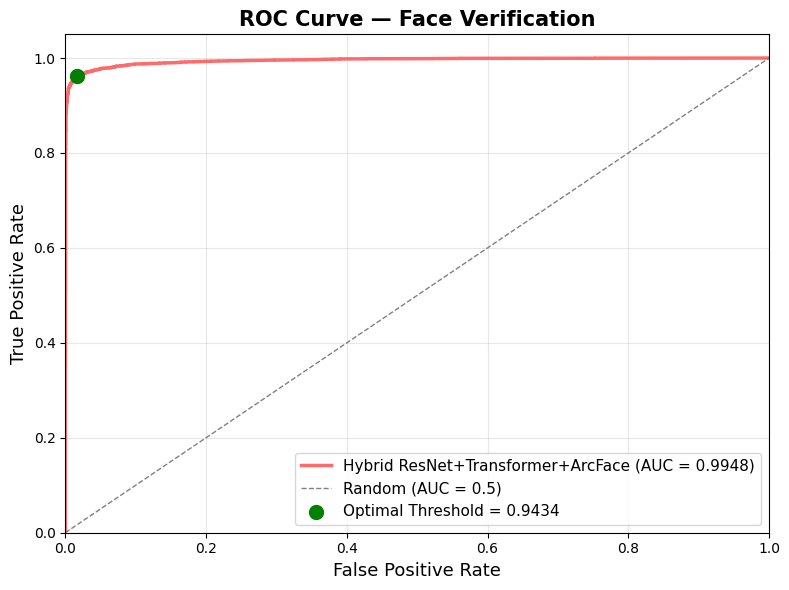

In [39]:
import json
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Load the results
with open('results.json', 'r') as f:
    results = json.load(f)

true_labels = results['true_labels']
pred_scores = results['pred_scores']

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, pred_scores)
roc_auc = auc(fpr, tpr)

# Find the optimal threshold (closest to top-left corner)
optimal_idx = (tpr - fpr).argmax()
optimal_thresh = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_thresh:.4f}")
print(f"At optimal threshold -> TPR: {tpr[optimal_idx]:.4f}, FPR: {fpr[optimal_idx]:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#FF6B6B', lw=2.5, label=f'Hybrid ResNet+Transformer+ArcFace (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random (AUC = 0.5)')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='green', s=100, zorder=5, label=f'Optimal Threshold = {optimal_thresh:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve — Face Verification', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
